# TransUNet for Medical Image Classification
## Dataset: Pneumonia Detection (Chest X-Ray)

This notebook adapts **TransUNet** for **binary image classification** of Pneumonia vs Normal chest X-rays.
Same architecture as the TB experiment — only the dataset config below changes.
This experiment uses the same imaging modality as TB (chest X-ray) but a different disease,
demonstrating that the adapted TransUNet generalises **across diseases within the same modality**.

### Dataset
- Source: Chest X-Ray Images (Pneumonia) — Paul Mooney (Kaggle)
- Link: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
- Classes: Normal vs Pneumonia (binary)
- Size: 5,856 images (1,583 Normal · 4,273 Pneumonia)
- Modality: Chest X-ray

### Note on Class Imbalance
This dataset is naturally imbalanced at approximately 1:2.7 (Normal:Pneumonia),
reflecting the real-world clinical distribution where pneumonia cases are more
frequently imaged. The dataset was used as-is without balancing to preserve
this clinical relevance. AUC-ROC is therefore the primary evaluation metric
as it is robust to class imbalance, with accuracy and F1 reported additionally
for completeness.

### Note on Dataset Preparation
The original Kaggle download comes pre-split into train, val, and test folders.
The validation set contains only 16 images total (8 per class), which is insufficient
for meaningful validation. All splits were therefore merged and re-split 80/10/10
using the same random seed as all other experiments to ensure a consistent
and reproducible evaluation setup across the study.

## Section 1: Setup & Installs

In [ ]:
# connecting to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install kagglehub
!pip install -q kagglehub

import kagglehub
import shutil

# Download the dataset (goes to a Colab cache folder first)
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print(f"Downloaded to cache: {path}")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Downloaded to cache: /kaggle/input/chest-xray-pneumonia


In [ ]:
import os

# Move it straight into your Drive so it persists
DEST = '/content/drive/MyDrive/TransUNet_Classification/Datasets/chest_xray_pneumonia'
os.makedirs(DEST, exist_ok=True)
shutil.copytree(path, DEST, dirs_exist_ok=True)

print(f"Dataset saved to Drive: {DEST}")

Dataset saved to Drive: /content/drive/MyDrive/TransUNet_Classification/Datasets/chest_xray_pneumonia


In [ ]:
# Install required packages
!pip install -q timm ml_collections

# Clone TransUNet repo (provides the ViT + hybrid encoder)
!git clone https://github.com/Beckschen/TransUNet.git

print("Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 4.5 MB/s eta 0:00:00
Cloning into 'TransUNet'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 128 (delta 71), reused 48 (delta 48), pack-reused 40 (from 1)
Receiving objects: 100% (128/128), 47.00 KiB | 4.70 MiB/s, done.
Resolving deltas: 100% (71/71), done.
Done!


In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

# Add TransUNet to path
sys.path.insert(0, '/content/TransUNet')

from networks.vit_seg_modeling import VisionTransformer as ViT_seg
from networks.vit_seg_modeling import CONFIGS as VIT_CONFIGS

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


## Section 2: Configuration
**Only change this cell when adapting to a new dataset.**

In [ ]:
import os
import shutil
from pathlib import Path

# Where Kaggle put the data
SOURCE = '/content/drive/MyDrive/TransUNet_Classification/Datasets/chest_xray_pneumonia/chest_xray'

# Where we want the clean merged version
DEST = '/content/drive/MyDrive/TransUNet_Classification/Datasets/Pneumonia_Merged'

# Create destination folders
for cls in ['NORMAL', 'PNEUMONIA']:
    os.makedirs(os.path.join(DEST, cls), exist_ok=True)

# Merge train + val + test into one folder per class
for split in ['train', 'val', 'test']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        src_folder = os.path.join(SOURCE, split, cls)
        dst_folder = os.path.join(DEST, cls)

        if not os.path.exists(src_folder):
            continue

        for img_file in os.listdir(src_folder):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                src_path = os.path.join(src_folder, img_file)
                # Rename to avoid filename clashes between splits
                dst_path = os.path.join(dst_folder, f"{split}_{img_file}")
                shutil.copy2(src_path, dst_path)

# Confirm counts
for cls in ['NORMAL', 'PNEUMONIA']:
    count = len(os.listdir(os.path.join(DEST, cls)))
    print(f"{cls}: {count} images")

NORMAL: 1583 images
PNEUMONIA: 4273 images


In [ ]:
# ============================================================
#  DATASET CONFIG — edit this block for each new dataset
# ============================================================

DATASET_NAME  = 'Pneumonia'
DATASET_PATH  = '/content/drive/MyDrive/TransUNet_Classification/Datasets/Pneumonia_Merged'
SAVE_DIR      = '/content/drive/MyDrive/TransUNet_Classification/Results/Pneumonia'
CLASS_NAMES   = ['NORMAL', 'PNEUMONIA']
NUM_CLASSES   = 2
DATASET_TYPE  = 'folder'

# CSV-only fields (leave as None for folder datasets)
CSV_PATH       = None
IMG_DIR        = None
IMG_COL        = None   # column name for image filename in CSV
LABEL_COL      = None   # column name for label in CSV

# ============================================================
#  TRAINING CONFIG
# ============================================================
IMG_SIZE       = 224
BATCH_SIZE     = 32
NUM_EPOCHS     = 30
LEARNING_RATE  = 1e-4
RANDOM_SEED    = 42

# Paths for saved weights
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, 'metric_images'), exist_ok=True)

TRANSUNET_WEIGHTS = os.path.join(SAVE_DIR, f'transunet_{DATASET_NAME.lower()}_best.pth')
DENSENET_WEIGHTS  = os.path.join(SAVE_DIR, f'densenet_{DATASET_NAME.lower()}_best.pth')

print(f'Dataset      : {DATASET_NAME}')
print(f'Dataset path : {DATASET_PATH}')
print(f'Save dir     : {SAVE_DIR}')
print(f'Classes      : {CLASS_NAMES}')
print(f'Device       : {device}')

Dataset      : Pneumonia
Dataset path : /content/drive/MyDrive/TransUNet_Classification/Datasets/Pneumonia_Merged
Save dir     : /content/drive/MyDrive/TransUNet_Classification/Results/Pneumonia
Classes      : ['NORMAL', 'PNEUMONIA']
Device       : cuda


## Section 3: Dataset Loading

In [ ]:
# ── Folder-based dataset (TB, Pneumonia, Brain Tumor) ──────────────────────
class FolderDataset(Dataset):
    """
    Loads images from a directory where each class has its own subfolder.
    Expected structure:
        root_dir/
            class_a/  img1.jpg  img2.png ...
            class_b/  img1.jpg  img2.png ...
    """
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        for cls in self.classes:
            cls_folder = os.path.join(root_dir, cls)
            if not os.path.isdir(cls_folder):
                continue
            for img_file in os.listdir(cls_folder):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(cls_folder, img_file), self.class_to_idx[cls]))

        print(f'Dataset loaded: {len(self.samples)} images | Classes: {self.class_to_idx}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path)
        if self.transform:
            image = self.transform(image)
        return image, label


# ── CSV-based dataset (ISIC Melanoma) ──────────────────────────────────────
class CSVDataset(Dataset):
    """
    Loads images from a directory using a CSV manifest.
    Used for ISIC-style datasets where labels live in a CSV, not folder names.

    CSV must have at minimum:
        - img_col  : image filename (without extension, e.g. 'ISIC_0000000')
        - label_col: integer label (0 or 1)
    """
    def __init__(self, csv_path, img_dir, img_col, label_col, img_ext='.jpg', transform=None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.img_col = img_col
        self.label_col = label_col
        self.img_ext = img_ext
        self.transform = transform
        print(f'CSV dataset loaded: {len(self.df)} images')
        print(f'Label distribution:\n{self.df[label_col].value_counts()}')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, str(row[self.img_col]) + self.img_ext)
        image = Image.open(img_path).convert('RGB')
        label = int(row[self.label_col])
        if self.transform:
            image = self.transform(image)
        return image, label


# ── Wrapper to apply different transforms to each split ────────────────────
class TransformSubset(Dataset):
    """Wraps a Subset and applies a transform to it."""
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


print('Dataset classes defined!')

Dataset classes defined!


In [ ]:
# Load the full dataset (no transforms yet — applied per split below)
if DATASET_TYPE == 'folder':
    full_dataset = FolderDataset(root_dir=DATASET_PATH, transform=None)
elif DATASET_TYPE == 'csv':
    full_dataset = CSVDataset(
        csv_path=CSV_PATH, img_dir=IMG_DIR,
        img_col=IMG_COL, label_col=LABEL_COL, transform=None
    )

# Explore class distribution
if DATASET_TYPE == 'folder':
    print('\nClass counts:')
    for cls in full_dataset.classes:
        cls_path = os.path.join(DATASET_PATH, cls)
        print(f'  {cls}: {len(os.listdir(cls_path))} images')

Dataset loaded: 5856 images | Classes: {'NORMAL': 0, 'PNEUMONIA': 1}

Class counts:
  NORMAL: 1583 images
  PNEUMONIA: 4273 images


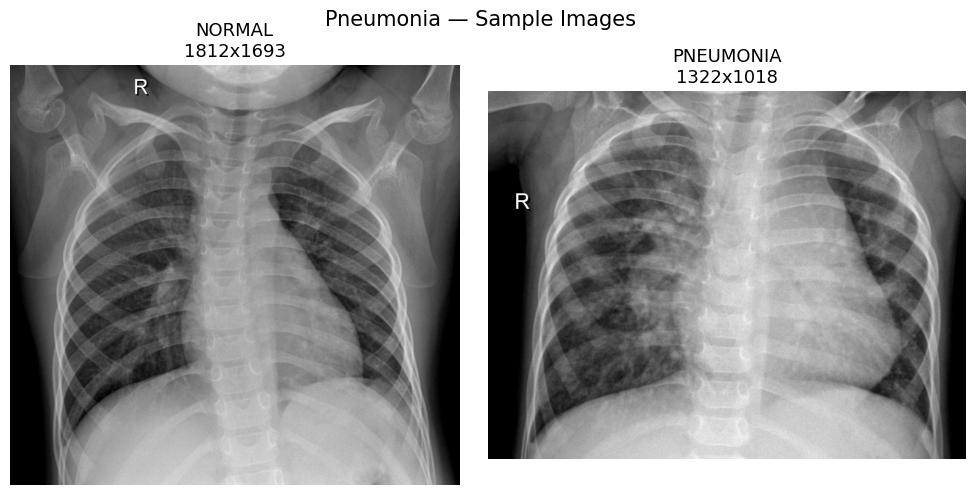

In [ ]:
# Visualize one sample from each class
if DATASET_TYPE == 'folder':
    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(5 * NUM_CLASSES, 5))
    if NUM_CLASSES == 2:
        axes = [axes] if NUM_CLASSES == 1 else axes
    for idx, cls in enumerate(full_dataset.classes):
        cls_path = os.path.join(DATASET_PATH, cls)
        sample_img = Image.open(os.path.join(cls_path, os.listdir(cls_path)[0]))
        axes[idx].imshow(sample_img, cmap='gray' if sample_img.mode == 'L' else None)
        axes[idx].set_title(f'{cls}\n{sample_img.size[0]}x{sample_img.size[1]}', fontsize=13)
        axes[idx].axis('off')
    plt.suptitle(f'{DATASET_NAME} — Sample Images', fontsize=15)
    plt.tight_layout()
    plt.show()

## Section 4: Preprocessing & Data Splits

In [ ]:
# Training transforms — with augmentation
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(lambda img: img.convert('RGB')),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation / Test transforms — no augmentation
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(lambda img: img.convert('RGB')),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Split sizes: 80 / 10 / 10
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size   = int(0.1 * total_size)
test_size  = total_size - train_size - val_size

print(f'Total   : {total_size}')
print(f'Train   : {train_size}')
print(f'Val     : {val_size}')
print(f'Test    : {test_size}')

# Split with fixed seed for reproducibility
train_subset, val_subset, test_subset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)

# Attach transforms
train_dataset = TransformSubset(train_subset, transform=train_transforms)
val_dataset   = TransformSubset(val_subset,   transform=val_test_transforms)
test_dataset  = TransformSubset(test_subset,  transform=val_test_transforms)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'\nTrain batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

# Sanity check
images, labels = next(iter(train_loader))
print(f'\nBatch shape : {images.shape}')  # [32, 3, 224, 224]
print(f'Labels      : {labels[:8].tolist()}')

Total   : 5856
Train   : 4684
Val     : 585
Test    : 587

Train batches : 147
Val batches   : 19
Test batches  : 19

Batch shape : torch.Size([32, 3, 224, 224])
Labels      : [1, 1, 1, 0, 1, 1, 1, 0]


## Section 5: Model Architectures
### 5a: TransUNet Classifier (the novel contribution)

Standard TransUNet: ResNet50 encoder → ViT transformer → UNet decoder → segmentation output  
**Our adaptation:** ResNet50 encoder → ViT transformer → **Global Average Pooling → Classification head**

The decoder is discarded entirely. We pool over all patch token representations
(mean across the sequence dimension) to get a single feature vector, then classify.

In [ ]:
class TransUNetClassifier(nn.Module):
    """
    TransUNet adapted for image classification.

    Architecture change vs original TransUNet:
    - Decoder (upsampling + segmentation head) is replaced by:
        1. Global Average Pooling over transformer patch tokens
        2. LayerNorm + Dropout + Linear classification head

    This allows the model to be used as a general-purpose classifier
    without any task-specific pretraining.

    Args:
        config      : TransUNet config (from VIT_CONFIGS)
        num_classes : number of output classes
        img_size    : input image size (default 224)
    """
    def __init__(self, config, num_classes=2, img_size=224):
        super(TransUNetClassifier, self).__init__()

        # Load the full TransUNet (we only use the encoder + transformer)
        self.transunet = ViT_seg(config, img_size=img_size, num_classes=num_classes)

        hidden_size = config.hidden_size  # 768 for ViT-B_16

        # Classification head replaces the segmentation decoder
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),     # stabilizes transformer outputs
            nn.Dropout(p=0.5),             # regularization
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        # Forward through ResNet encoder + ViT transformer
        # x: [batch, 3, H, W]
        x, attn_weights, features = self.transunet.transformer(x)
        # x: [batch, num_patches, hidden_size]

        # Global average pooling over patch tokens → [batch, hidden_size]
        # Alternative: use x[:, 0, :] if CLS token is available
        x = x.mean(dim=1)

        # Classify
        return self.classifier(x)


def build_transunet(num_classes=2, img_size=224):
    """Build and return a TransUNetClassifier with standard R50-ViT-B_16 config."""
    config = VIT_CONFIGS['R50-ViT-B_16']
    config.n_classes = num_classes
    config.n_skip = 3
    config.patches.grid = (img_size // 16, img_size // 16)  # e.g. 14x14 for 224
    config.pretrained_path = None  # training from scratch
    model = TransUNetClassifier(config, num_classes=num_classes, img_size=img_size)
    return model


print('TransUNetClassifier defined!')

TransUNetClassifier defined!


### 5b: DenseNet-121 Baseline

In [ ]:
class DenseNetClassifier(nn.Module):
    """
    DenseNet-121 fine-tuned for binary/multi-class classification.
    Uses ImageNet pretrained weights — serves as the strong baseline.

    Args:
        num_classes : number of output classes
        pretrained  : use ImageNet pretrained weights (default True)
    """
    def __init__(self, num_classes=2, pretrained=True):
        super(DenseNetClassifier, self).__init__()
        self.model = models.densenet121(pretrained=pretrained)
        in_features = self.model.classifier.in_features  # 1024
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)


print('DenseNetClassifier defined!')

DenseNetClassifier defined!


## Section 6: Training Utilities

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    """Run one full training epoch. Returns (loss, accuracy)."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc='Training', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / len(loader), correct / total * 100


def validate(model, loader, criterion):
    """Run validation (no gradient updates). Returns (loss, accuracy)."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validating', leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / len(loader), correct / total * 100


def run_training(model, model_name, save_path, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE):
    """
    Full training loop with early stopping via best-val-loss tracking.

    Returns:
        history (dict): train/val loss and accuracy per epoch
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=3, factor=0.5
    )

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')

    print(f'\n{"="*50}')
    print(f'Training: {model_name}')
    print(f'{"="*50}')

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc     = validate(model, val_loader, criterion)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'Epoch [{epoch+1:02d}/{num_epochs}] | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%', end='')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(' ← best saved', end='')
        print()

    # Save history CSV
    hist_df = pd.DataFrame(history)
    hist_path = os.path.join(SAVE_DIR, f'{model_name.lower().replace(" ","_")}_history.csv')
    hist_df.to_csv(hist_path, index=False)

    print(f'\nTraining complete! Best val loss: {best_val_loss:.4f}')
    print(f'Weights saved to  : {save_path}')
    print(f'History saved to  : {hist_path}')
    return history


print('Training utilities ready!')

Training utilities ready!


## Section 7: Evaluation Utilities

In [ ]:
def evaluate_model(model, weights_path, model_name):
    """
    Load best weights and evaluate on the test set.
    Returns dict of metrics and raw prediction arrays.
    """
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.eval()

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f'Testing {model_name}'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    acc     = accuracy_score(all_labels, all_preds) * 100
    f1      = f1_score(all_labels, all_preds, average='weighted') * 100
    auc_roc = roc_auc_score(all_labels, all_probs) * 100

    print(f'\n{"="*50}')
    print(f'  {model_name} — {DATASET_NAME} Test Results')
    print(f'{"="*50}')
    print(f'  Accuracy : {acc:.2f}%')
    print(f'  F1 Score : {f1:.2f}%')
    print(f'  AUC-ROC  : {auc_roc:.2f}%')
    print(f'{"="*50}')
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

    return {
        'model_name': model_name,
        'accuracy':   acc,
        'f1':         f1,
        'auc_roc':    auc_roc,
        'preds':      all_preds,
        'labels':     all_labels,
        'probs':      all_probs
    }


print('Evaluation utilities ready!')

Evaluation utilities ready!


## Section 8: Visualization Utilities

In [ ]:
def plot_training_history(history, model_name):
    """Plot and save loss + accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
    axes[0].plot(history['val_loss'],   label='Val Loss',   color='coral',     linewidth=2)
    axes[0].set_title('Loss Over Epochs', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['train_acc'], label='Train Accuracy', color='steelblue', linewidth=2)
    axes[1].plot(history['val_acc'],   label='Val Accuracy',   color='coral',     linewidth=2)
    axes[1].set_title('Accuracy Over Epochs', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'{model_name} — {DATASET_NAME} Training History', fontsize=15)
    plt.tight_layout()

    save_path = os.path.join(SAVE_DIR, 'metric_images',
                             f'{model_name.lower().replace(" ","_")}_training_history.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


def plot_confusion_matrix(results):
    """Plot and save confusion matrix."""
    cm = confusion_matrix(results['labels'], results['preds'])
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"{results['model_name']} — {DATASET_NAME} Confusion Matrix", fontsize=13)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()

    save_path = os.path.join(SAVE_DIR, 'metric_images',
                             f"{results['model_name'].lower().replace(' ','_')}_confusion_matrix.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


def plot_roc_curve(results):
    """Plot and save ROC curve."""
    fpr, tpr, _ = roc_curve(results['labels'], results['probs'])
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f"AUC = {results['auc_roc']:.2f}%")
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
    plt.title(f"{results['model_name']} — {DATASET_NAME} ROC Curve", fontsize=13)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_path = os.path.join(SAVE_DIR, 'metric_images',
                             f"{results['model_name'].lower().replace(' ','_')}_roc_curve.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


def plot_comparison(results_list):
    """Bar chart comparing models side by side on all three metrics."""
    model_names = [r['model_name'] for r in results_list]
    metrics = ['accuracy', 'f1', 'auc_roc']
    metric_labels = ['Accuracy (%)', 'F1 Score (%)', 'AUC-ROC (%)']
    colors = ['steelblue', 'coral']

    x = np.arange(len(metrics))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 6))

    for i, result in enumerate(results_list):
        values = [result[m] for m in metrics]
        bars = ax.bar(x + i * width, values, width, label=result['model_name'], color=colors[i])
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 2,
                    f'{val:.2f}%', ha='center', va='top', fontsize=10, color='white', fontweight='bold')

    ax.set_ylim([85, 102])
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(metric_labels, fontsize=12)
    ax.set_ylabel('Score (%)', fontsize=12)
    ax.set_title(f'Model Comparison — {DATASET_NAME}', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()

    save_path = os.path.join(SAVE_DIR, 'metric_images', 'comparison_chart.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


print('Visualization utilities ready!')

Visualization utilities ready!


## Section 9: Train TransUNet

In [ ]:
# Build the model
transunet_model = build_transunet(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(device)

total_params = sum(p.numel() for p in transunet_model.parameters())
print(f'TransUNet total parameters: {total_params:,}')
print('Note: Training from scratch — no pretrained weights')

TransUNet total parameters: 105,279,140
Note: Training from scratch — no pretrained weights


In [ ]:
transunet_history = run_training(
    model=transunet_model,
    model_name='TransUNet',
    save_path=TRANSUNET_WEIGHTS,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE
)


Training: TransUNet


Epoch [01/30] | Train Loss: 0.5614 Acc: 74.72% | Val Loss: 0.3526 Acc: 83.93% ← best saved


Epoch [02/30] | Train Loss: 0.2751 Acc: 88.68% | Val Loss: 0.1738 Acc: 93.68% ← best saved


Epoch [03/30] | Train Loss: 0.2033 Acc: 92.34% | Val Loss: 0.2002 Acc: 91.62%


Epoch [04/30] | Train Loss: 0.1849 Acc: 92.95% | Val Loss: 0.2306 Acc: 90.43%


...

Epoch [26/30] | Train Loss: 0.0889 Acc: 96.95% | Val Loss: 0.1592 Acc: 93.33%


Epoch [27/30] | Train Loss: 0.0838 Acc: 97.12% | Val Loss: 0.1447 Acc: 94.70%


Epoch [28/30] | Train Loss: 0.0889 Acc: 96.65% | Val Loss: 0.1462 Acc: 94.53%


Epoch [29/30] | Train Loss: 0.0809 Acc: 97.14% | Val Loss: 0.1528 Acc: 94.02%


Epoch [30/30] | Train Loss: 0.0872 Acc: 96.80% | Val Loss: 0.1436 Acc: 94.70%

Training complete! Best val loss: 0.1324
Weights saved to  : /content/drive/MyDrive/TransUNet_Classification/Results/Pneumonia/transunet_pneumonia_best.pth
History saved to  : /content/drive/MyDrive/TransUNet_Classification/Results/Pneumonia/transunet_history.csv


## Section 10: Train DenseNet-121 (Baseline)

In [ ]:
densenet_model = DenseNetClassifier(num_classes=NUM_CLASSES, pretrained=True).to(device)

total_params = sum(p.numel() for p in densenet_model.parameters())
print(f'DenseNet-121 total parameters: {total_params:,}')
print('Using ImageNet pretrained weights')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 177MB/s]


DenseNet-121 total parameters: 6,955,906
Using ImageNet pretrained weights


In [ ]:
densenet_history = run_training(
    model=densenet_model,
    model_name='DenseNet-121',
    save_path=DENSENET_WEIGHTS,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE
)


Training: DenseNet-121


Epoch [01/30] | Train Loss: 0.1937 Acc: 92.02% | Val Loss: 0.1276 Acc: 95.73% ← best saved


Epoch [02/30] | Train Loss: 0.1098 Acc: 96.05% | Val Loss: 0.1257 Acc: 96.41% ← best saved


Epoch [03/30] | Train Loss: 0.0893 Acc: 96.78% | Val Loss: 0.1417 Acc: 95.38%


Epoch [04/30] | Train Loss: 0.0813 Acc: 96.82% | Val Loss: 0.2012 Acc: 93.68%


...

Epoch [26/30] | Train Loss: 0.0030 Acc: 99.96% | Val Loss: 0.0972 Acc: 97.09%


Epoch [27/30] | Train Loss: 0.0026 Acc: 99.98% | Val Loss: 0.1259 Acc: 96.58%


Epoch [28/30] | Train Loss: 0.0047 Acc: 99.89% | Val Loss: 0.0787 Acc: 97.09%


Epoch [29/30] | Train Loss: 0.0034 Acc: 99.89% | Val Loss: 0.1057 Acc: 97.09%


Epoch [30/30] | Train Loss: 0.0017 Acc: 100.00% | Val Loss: 0.0950 Acc: 97.44%

Training complete! Best val loss: 0.0569
Weights saved to  : /content/drive/MyDrive/TransUNet_Classification/Results/Pneumonia/densenet_pneumonia_best.pth
History saved to  : /content/drive/MyDrive/TransUNet_Classification/Results/Pneumonia/densenet-121_history.csv


## Section 11: Evaluate & Visualize

In [ ]:
# Just define the path as a string
TRANSUNET_WEIGHTS = "/content/drive/MyDrive/TransUNet_Classification/Results/Pneumonia/transunet_pneumonia_best.pth"

# Pass the string path to the function
transunet_results = evaluate_model(transunet_model, TRANSUNET_WEIGHTS, 'TransUNet')


Testing TransUNet: 100%|██████████| 19/19 [01:14<00:00,  3.91s/it]


  TransUNet — Pneumonia Test Results
  Accuracy : 97.79%
  F1 Score : 97.80%
  AUC-ROC  : 99.77%
              precision    recall  f1-score   support

      NORMAL       0.95      0.98      0.96       162
   PNEUMONIA       0.99      0.98      0.98       425

    accuracy                           0.98       587
   macro avg       0.97      0.98      0.97       587
weighted avg       0.98      0.98      0.98       587



In [ ]:
densenet_results  = evaluate_model(densenet_model,  DENSENET_WEIGHTS,  'DenseNet-121')

Testing DenseNet-121: 100%|██████████| 19/19 [00:37<00:00,  1.95s/it]


  DenseNet-121 — Pneumonia Test Results
  Accuracy : 97.79%
  F1 Score : 97.80%
  AUC-ROC  : 99.90%
              precision    recall  f1-score   support

      NORMAL       0.94      0.99      0.96       162
   PNEUMONIA       1.00      0.97      0.98       425

    accuracy                           0.98       587
   macro avg       0.97      0.98      0.97       587
weighted avg       0.98      0.98      0.98       587



In [ ]:
DENSENET_WEIGHTS = "/content/drive/MyDrive/TransUNet_Classification/Results/Pneumonia/densenet_pneumonia_best.pth"

densenet_results  = evaluate_model(densenet_model,  DENSENET_WEIGHTS,  'DenseNet-121')

Testing DenseNet-121: 100%|██████████| 19/19 [00:09<00:00,  1.93it/s]


  DenseNet-121 — Pneumonia Test Results
  Accuracy : 97.79%
  F1 Score : 97.80%
  AUC-ROC  : 99.90%
              precision    recall  f1-score   support

      NORMAL       0.94      0.99      0.96       162
   PNEUMONIA       1.00      0.97      0.98       425

    accuracy                           0.98       587
   macro avg       0.97      0.98      0.97       587
weighted avg       0.98      0.98      0.98       587



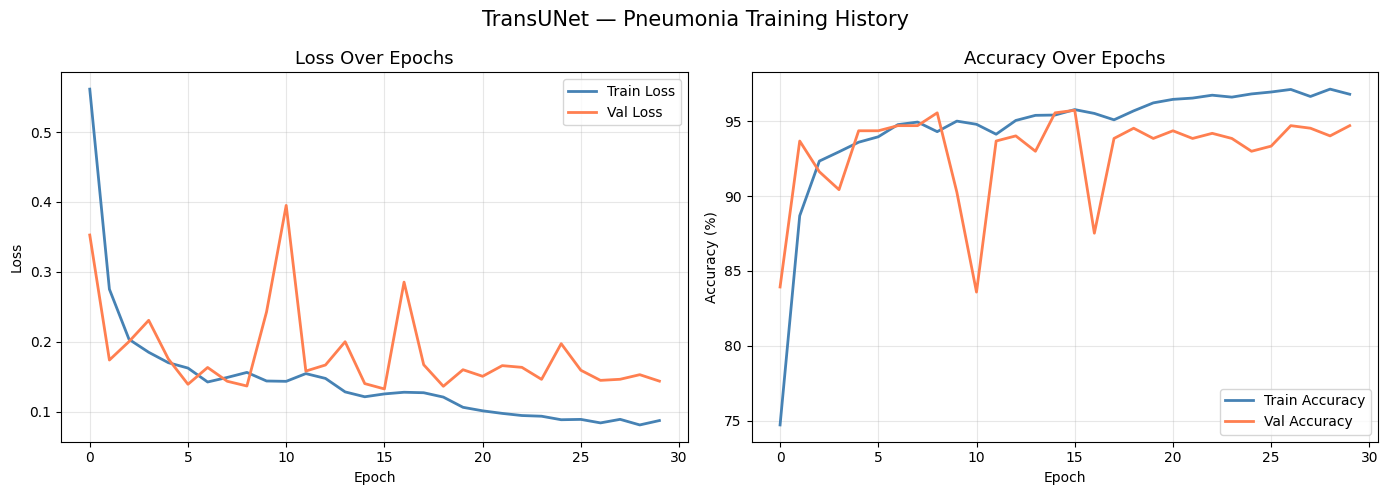

Saved: /content/drive/MyDrive/TransUNet_Classification/Results/Pneumonia/metric_images/transunet_training_history.png


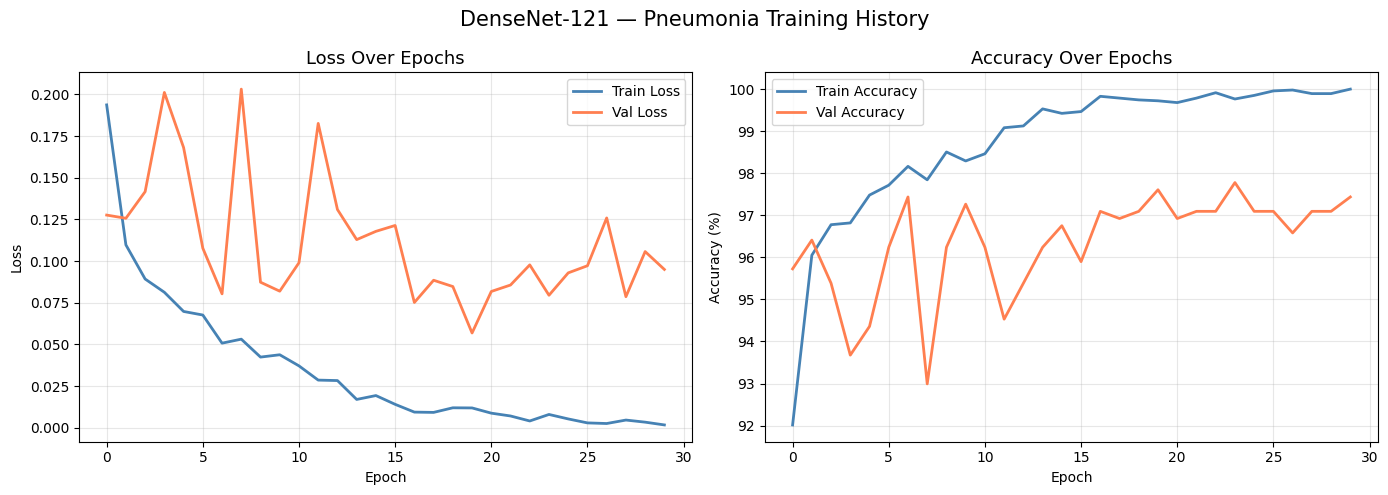

Saved: /content/drive/MyDrive/TransUNet_Classification/Results/Pneumonia/metric_images/densenet-121_training_history.png


In [ ]:
# Training curves
plot_training_history(transunet_history, 'TransUNet')
plot_training_history(densenet_history,  'DenseNet-121')

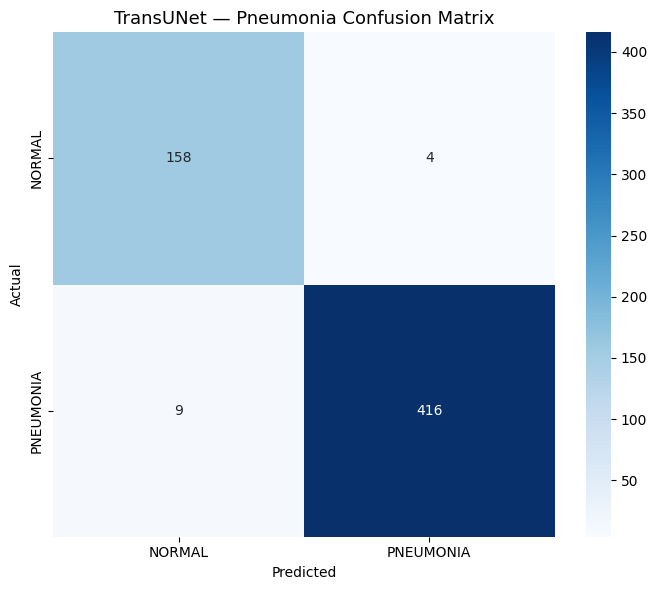

Saved: /content/drive/MyDrive/TransUNet_Classification/Results/Pneumonia/metric_images/transunet_confusion_matrix.png


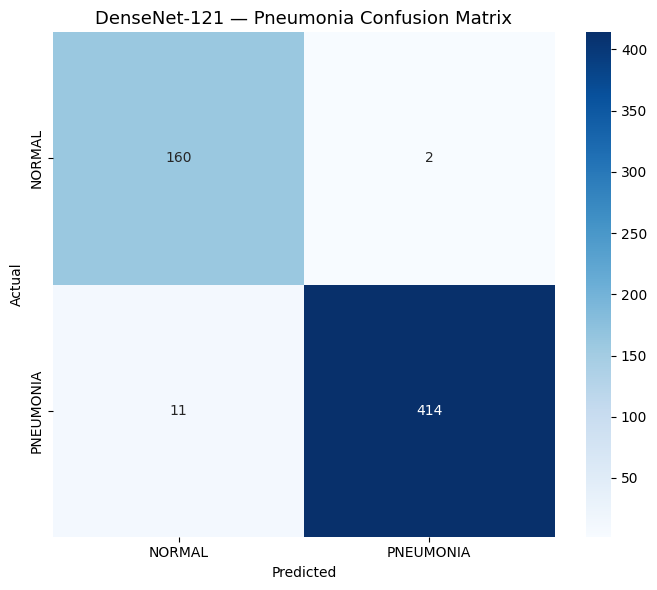

Saved: /content/drive/MyDrive/TransUNet_Classification/Results/Pneumonia/metric_images/densenet-121_confusion_matrix.png


In [ ]:
# Confusion matrices
plot_confusion_matrix(transunet_results)
plot_confusion_matrix(densenet_results)

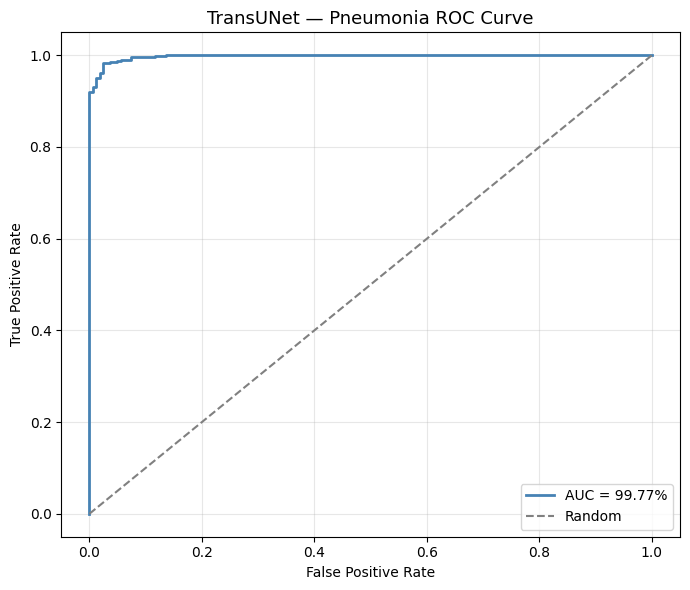

Saved: /content/drive/MyDrive/TransUNet_Classification/Results/Pneumonia/metric_images/transunet_roc_curve.png


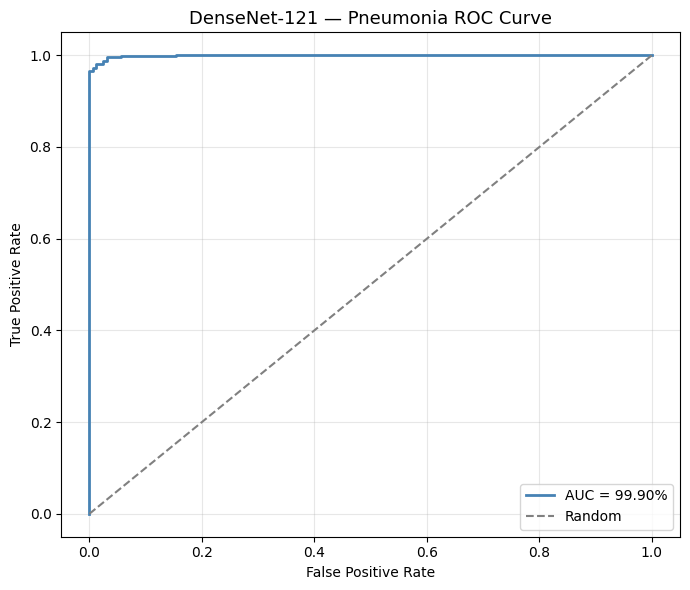

Saved: /content/drive/MyDrive/TransUNet_Classification/Results/Pneumonia/metric_images/densenet-121_roc_curve.png


In [ ]:
# ROC curves
plot_roc_curve(transunet_results)
plot_roc_curve(densenet_results)

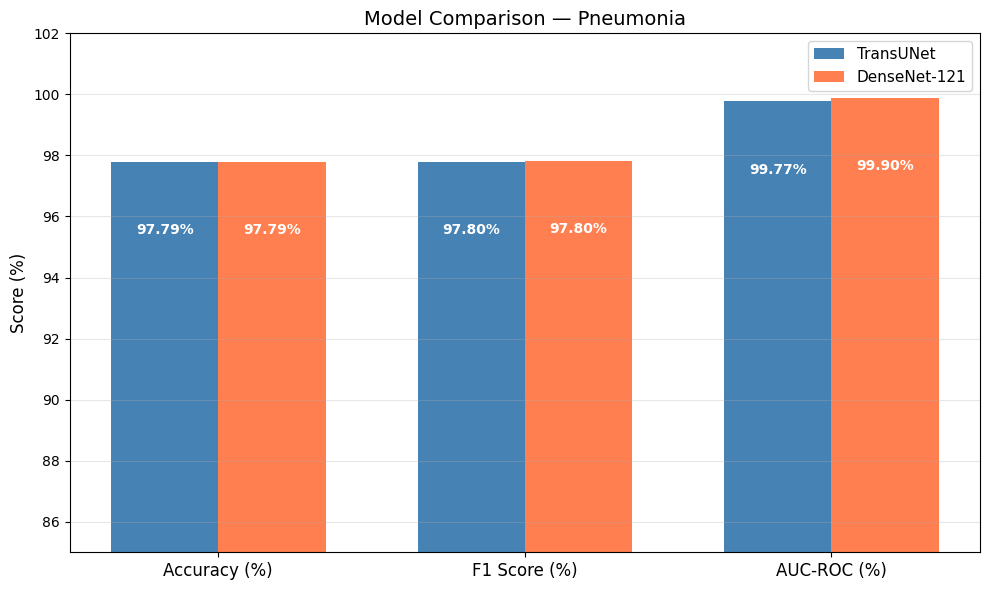

Saved: /content/drive/MyDrive/TransUNet_Classification/Results/Pneumonia/metric_images/comparison_chart.png


In [ ]:
# Side-by-side comparison
plot_comparison([transunet_results, densenet_results])

In [ ]:
# Final summary table
summary = pd.DataFrame([
    {
        'Model': r['model_name'],
        'Accuracy (%)': f"{r['accuracy']:.2f}",
        'F1 Score (%)':  f"{r['f1']:.2f}",
        'AUC-ROC (%)':   f"{r['auc_roc']:.2f}",
    }
    for r in [transunet_results, densenet_results]
])
print(f'\n{DATASET_NAME} — Final Results')
print(summary.to_string(index=False))

summary_path = os.path.join(SAVE_DIR, f'{DATASET_NAME.lower()}_results_summary.csv')
summary.to_csv(summary_path, index=False)
print(f'\nSummary saved to: {summary_path}')


Pneumonia — Final Results
       Model Accuracy (%) F1 Score (%) AUC-ROC (%)
   TransUNet        97.79        97.80       99.77
DenseNet-121        97.79        97.80       99.90

Summary saved to: /content/drive/MyDrive/TransUNet_Classification/Results/Pneumonia/pneumonia_results_summary.csv
